
# Title
# <img src="image.png" alt="Credit Risk Model Optimization Logo" height="100" style="vertical-align: middle; margin-centre: 80px;" /> Credit 


Fintech Innovations
## Overview


## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Business Understanding

### The Manual Review Problem

FinTech Innovations currently processes loan applications through individual loan officers. At scale, this creates two compounding problems. First, it's a throughput bottleneck — each review requires human time, and application volume doesn't wait. Second, different officers apply different standards to the same information. What one officer approves, another denies. That inconsistency is not just operationally messy; it creates regulatory exposure and erodes applicant trust.

A machine learning model addresses both. It applies the same decision criteria to every application and produces a decision — or a probability score for officer review — in milliseconds.

### Why Standard Accuracy Is the Wrong Target

Our historical data shows approximately 76% of past applications were denied. A model that predicts "deny" for every single applicant would achieve 76% accuracy while being completely useless. Accuracy treats every mistake equally. Our mistakes are not equal.

| Error Type | What It Means | Business Cost |
|---|---|---|
| **False Positive** | We approved a loan that defaulted | **$50,000** loss |
| **False Negative** | We denied a creditworthy applicant | **$8,000** lost profit |

A single bad approval costs 6.25× more than a missed good applicant. The model has to know the difference between "wrong in the expensive direction" and "wrong in the cheap direction." Raw accuracy cannot capture this.

### Classification vs. Regression

`LoanApproved` is binary — 0 (denied) or 1 (approved). This is a classification problem directly. A regression approach would predict a continuous risk score, which then requires an arbitrary cutoff to produce a decision anyway, adding a step without adding clarity. Classification gives us the binary outcome the business needs and lets us evaluate performance in terms of actual approval decisions.

Note: `RiskScore` exists in the dataset but was generated using `LoanApproved` as an input in its calculation. Including it as a feature would mean the model learns from the label it's supposed to predict. It must be dropped before modeling.

### Success Metrics

**Primary — ROC-AUC:** Measures how well the model separates approvals from denials across all possible probability thresholds. It handles class imbalance correctly, unlike accuracy. A random classifier scores 0.50. Target: ≥ 0.80 on the held-out test set.

**Secondary — Business Cost Metric:**

$$\text{Total Cost} = FP \times \$50{,}000 + FN \times \$8{,}000$$

Lower is better. This anchors model comparison in dollar terms rather than abstract statistics. When two models have similar AUC, the one with lower business cost is the one the bank should deploy.

**Baseline:** Always denying every application → AUC = 0.50, zero revenue captured, and $0 in default losses — but also $0 in lending income. Any model we build must outperform this on both dimensions.

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


## Data Understanding

### Dataset Overview

The dataset contains 20,000 loan applications and 35 columns. After removing three columns — `RiskScore` (uses the target label in its calculation), `MonthlyIncome` (exactly `AnnualIncome / 12`, zero added information), and `BaseInterestRate` (an intermediate computation; `InterestRate` is its final output) — we model on 31 features.

**Class distribution:** 15,220 denied (76.1%) vs. 4,780 approved (23.9%). The roughly 3:1 imbalance means we use stratified train/test splits and set `class_weight='balanced'` in all models.

### Feature Types

**Numerical (26 features):**
`Age`, `AnnualIncome`*, `CreditScore`, `Experience`, `LoanAmount`, `LoanDuration`, `NumberOfDependents`, `MonthlyDebtPayments`, `CreditCardUtilizationRate`, `NumberOfOpenCreditLines`, `NumberOfCreditInquiries`, `DebtToIncomeRatio`, `BankruptcyHistory`*, `PreviousLoanDefaults`, `PaymentHistory`, `LengthOfCreditHistory`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`, `TotalLiabilities`, `UtilityBillsPaymentHistory`, `JobTenure`, `NetWorth`, `InterestRate`, `MonthlyLoanPayment`, `TotalDebtToIncomeRatio`

**Ordinal (1 feature):**
`EducationLevel` — five ordered levels: High School < Associate < Bachelor < Master < Doctorate

**Categorical / Nominal (4 features):**
`EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `LoanPurpose`

### Data Quality Issues

| Column | Issue | Fix |
|---|---|---|
| `AnnualIncome` | Stored as currency string: `"$39,948.00"` | Strip `$` and `,`, cast to float |
| `BankruptcyHistory` | Stored as `"Yes"` / `"No"` strings | Map to 1 / 0 |
| `MaritalStatus` | 1,331 missing values (~6.7%) | Impute with mode in pipeline |
| `EducationLevel` | 901 missing values (~4.5%) | Impute with mode in pipeline |
| `SavingsAccountBalance` | 572 missing values (~2.9%) | Impute with median in pipeline |

The two manual fixes (`AnnualIncome`, `BankruptcyHistory`) happen before the pipeline because they change the column's dtype — the pipeline can't impute or scale a currency string.

In [34]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay, make_scorer
)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

In [35]:
# EDA Code Here - Create New Cells As Needed
df = pd.read_csv("financial_loan_data.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [36]:
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354,1,2,0.358,No,Home,0,29,9,7632.000,1202,146111,19183,3329.000,0.725,11,126928,0.200,0.228,419.806,0.181,0,49.000
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.088,5,3,0.330,No,Debt Consolidation,0,21,9,4627.000,3460,53204,9595,3309.083,0.935,3,43609,0.207,0.201,794.054,0.390,0,52.000
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137,2,0,0.245,No,Education,0,20,22,886.000,895,25176,128874,3393.667,0.872,6,5205,0.218,0.213,666.407,0.462,0,52.000
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.268,2,1,0.436,No,Home,0,27,10,1675.000,1217,104822,5370,5757.000,0.896,5,99452,0.300,0.301,1047.507,0.313,0,54.000
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.321,0,0,0.079,No,Debt Consolidation,0,26,27,1555.000,4981,244305,17286,8605.333,0.941,5,227019,0.197,0.176,330.179,0.070,1,36.000


In [37]:
df.duplicated()
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

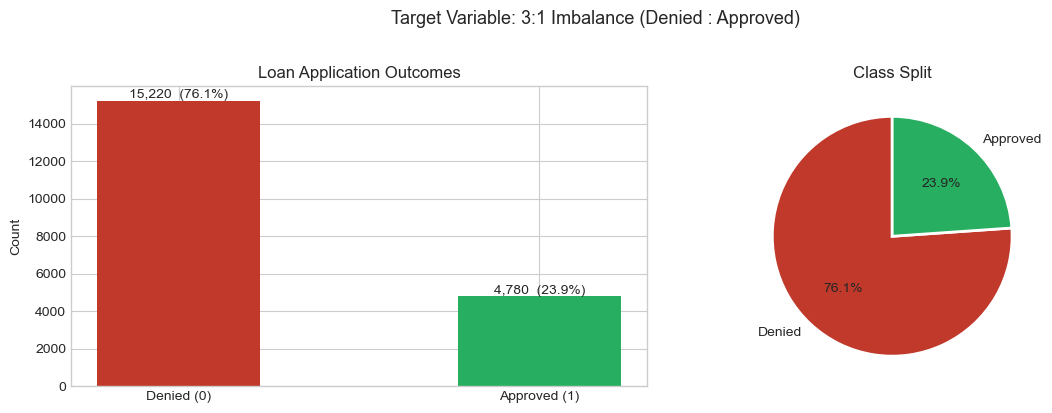

In [38]:
# EDA Code Here - Create New Cells As Needed
# ── 1. Class Distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['LoanApproved'].value_counts().sort_index()
axes[0].bar(['Denied (0)', 'Approved (1)'], counts.values,
            color=['#c0392b', '#27ae60'], width=0.45)
axes[0].set_title('Loan Application Outcomes', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 120, f'{v:,}  ({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

axes[1].pie(counts.values, labels=['Denied', 'Approved'],
            colors=['#c0392b', '#27ae60'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Split', fontsize=12)

plt.suptitle('Target Variable: 3:1 Imbalance (Denied : Approved)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

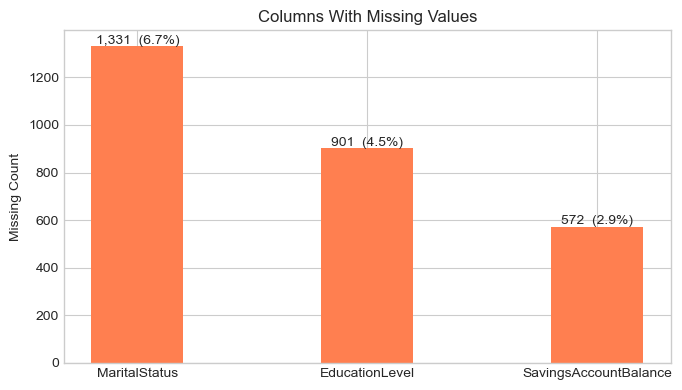

In [39]:
# ── 3. Missing Value Bar Chart ────────────────────────────────────────────────
missing_data = df[['MaritalStatus', 'EducationLevel', 'SavingsAccountBalance']].isnull().sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(missing_data.index, missing_data.values, color='coral', width=0.4)
ax.set_title('Columns With Missing Values', fontsize=12)
ax.set_ylabel('Missing Count')
for bar, (col, v) in zip(bars, missing_data.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 10,
            f'{v:,}  ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

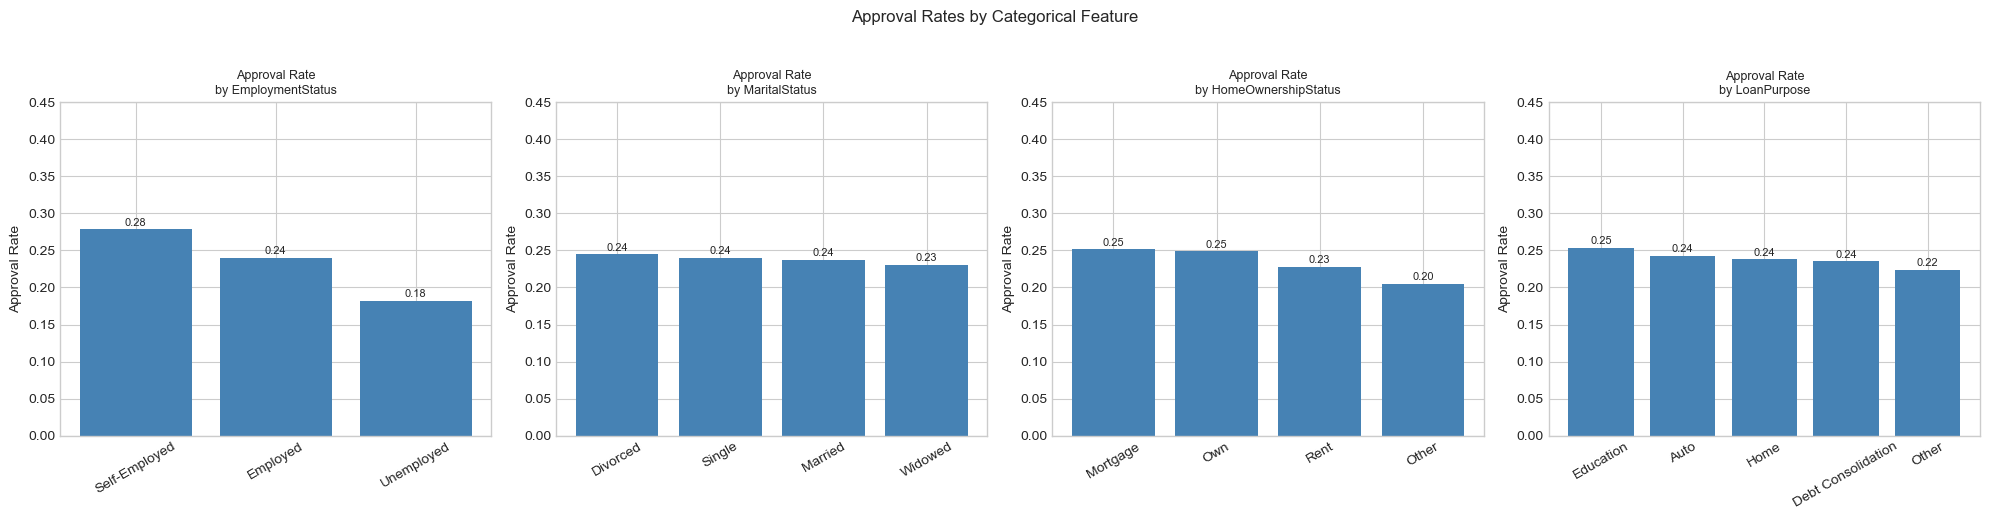

In [40]:
# ── 4. Approval Rate Across Categorical Features ──────────────────────────────
cat_plot_cols = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, cat_plot_cols):
    rates = (df.groupby(col, dropna=True)['LoanApproved']
               .mean()
               .sort_values(ascending=False))
    bars = ax.bar(rates.index, rates.values, color='steelblue')
    ax.set_title(f'Approval Rate\nby {col}', fontsize=9)
    ax.set_ylabel('Approval Rate')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 0.45)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                f'{val:.2f}', ha='center', fontsize=8)

plt.suptitle('Approval Rates by Categorical Feature', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

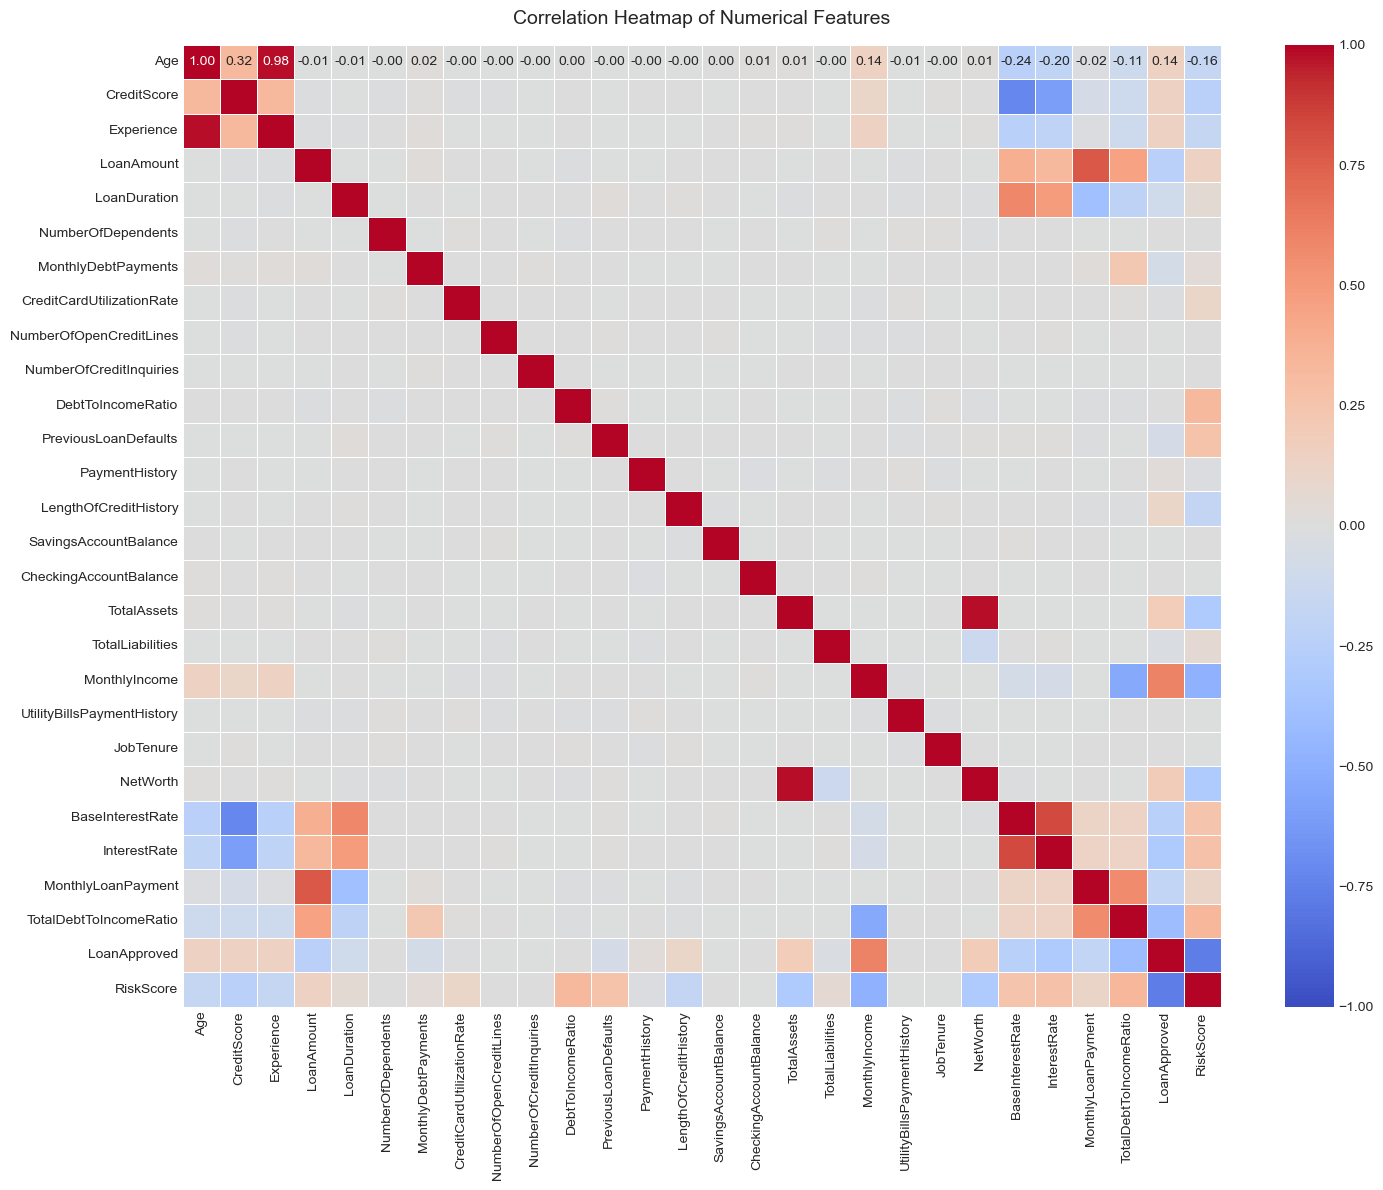

In [41]:
# 1. Filter out only numerical columns
numerical_df = df.select_dtypes(include=['number'])
# 2. Calculate the correlation matrix
correlation_matrix = numerical_df.corr()
# 3. Generate the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show correlation values inside the squares
    cmap='coolwarm',     # Color gradient (blue = negative, red = positive)
    fmt=".2f",           # Round values to 2 decimal places
    linewidths=0.5,      # Add a thin white border between cells
    vmin=-1, vmax=1      # Set colorbar limits to full correlation range
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [42]:
# Data Prep Code Here - Create New Cells As Needed
X = df.drop(columns=["LoanApproved"])
y = df["LoanApproved"]

In [43]:
# Splitting the data 
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
# Filtering the data. Separating the categorical columns and the numerical columns
categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
print(categorical_cols)
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
print(numerical_cols)

['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']


In [45]:
# for the categorical columns, the missing values are first filled with the most_frequent within the column and then encoded using the OneHotEncoder
# for the numerical columns, the mission values are filled with the median and then scaled by StandardScaler 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

In [46]:
# Preprocessor: applies numeric and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [47]:
#  Modeling Code Here - Create New Cells as Needed
# Full pipeline with model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'  # Highly recommended for imbalanced loan data
    ))
])

# 2. Fit the pipeline (ensure y_train contains integer classes)
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries',
                                                   'De...
                                                   'RiskScore']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['AnnualIncome',
                                                   'EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [48]:
param_grid = {
    'classifier__max_depth':[50,100, 200], 
    'classifier__n_estimators':[100, 200 ], 
    'classifier__min_samples_split':[10,20,30,40,50],     
    'classifier__max_features': ['sqrt', 'log2']  
}
# 3. Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring='f1',   
    cv=5,
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)
# 4. Fit and clean data targets
grid_search.fit(X_train, y_train.astype(int))

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'classifier__max_depth': 200, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 30, 'classifier__n_estimators': 200}
Best CV F1-score: 0.9615799562192583


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [49]:
# Extract your optimal Random Forest model pipeline
final_model = grid_search.best_estimator_
# Run predictions on your holdout test set
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]
# --- PART A: Assess Test Data Performance ---
print("=== RANDOM FOREST TEST PERFORMANCE ===")
# Force y_test to integers to avoid metric mismatches
print(classification_report(y_test.astype(int), y_pred, target_names=['Approved', 'Default']))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test.astype(int), y_proba):.4f}\n")

=== RANDOM FOREST TEST PERFORMANCE ===
              precision    recall  f1-score   support

    Approved       0.99      0.99      0.99      3044
     Default       0.96      0.96      0.96       956

    accuracy                           0.98      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.98      0.98      0.98      4000

Final Test ROC-AUC Score: 0.9970



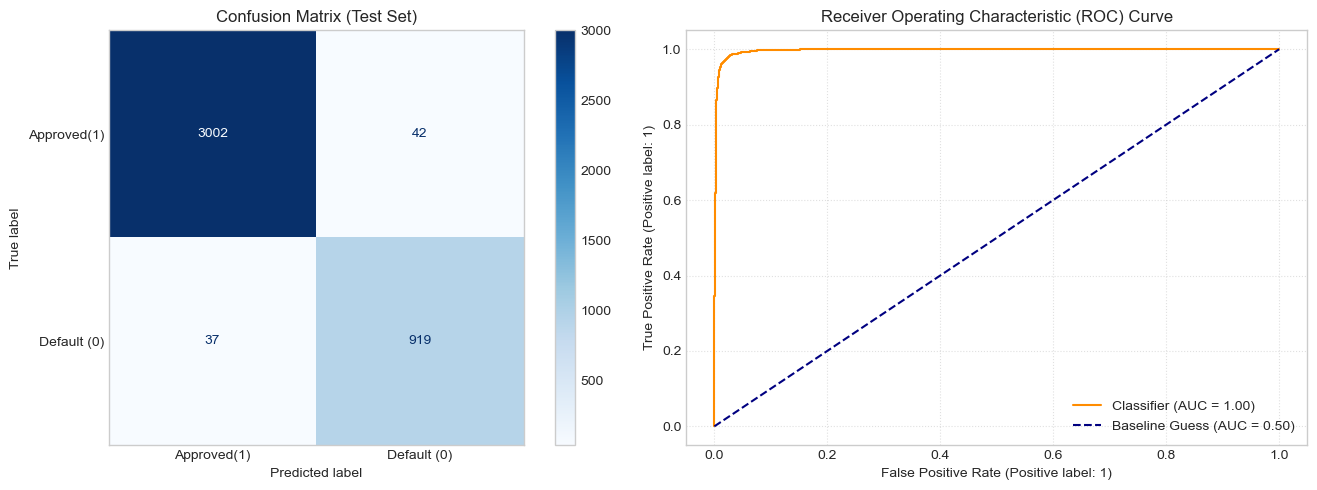

In [50]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
# 1. Create the side-by-side plot layout (axes is an array of 2 subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Confusion Matrix -> Assign explicitly to axes[0]
cm = confusion_matrix(y_test.astype(int), y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Approved(1)', 'Default (0)'])
cm_display.plot(ax=axes[0], cmap='Blues', values_format='d')  # Fixed indexing here
axes[0].set_title('Confusion Matrix (Test Set)')
axes[0].grid(False) # Clear gridlines over the matrix for visual cleanliness
# Plot 2: ROC-AUC Curve -> Assign explicitly to axes[1]
roc_display = RocCurveDisplay.from_predictions(y_test.astype(int), y_proba, ax=axes[1], color='darkorange') # Fixed indexing here
# Added the explicit x and y coordinates for the diagonal baseline
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--', label='Baseline Guess (AUC = 0.50)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


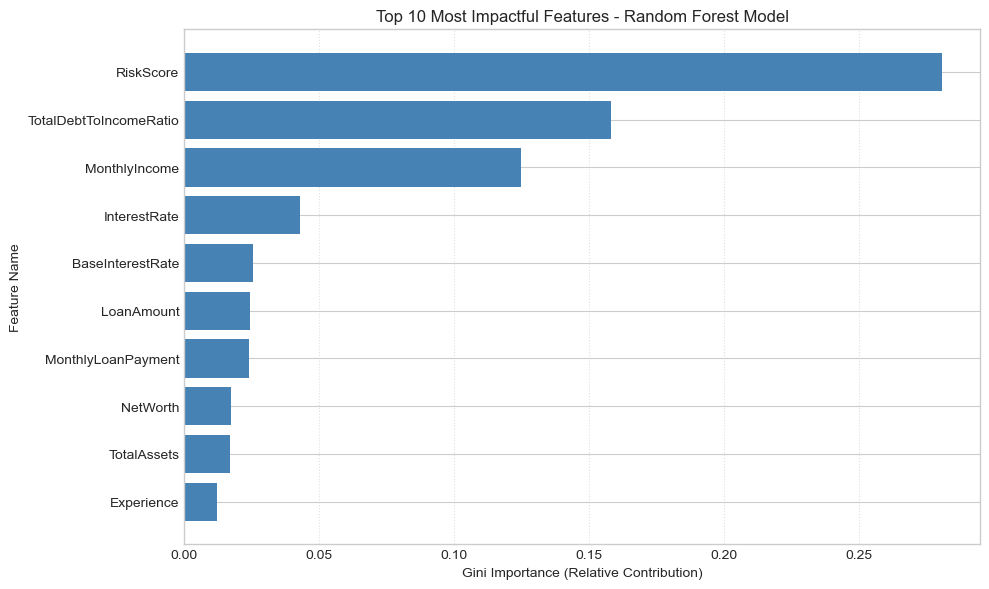

TOP 5 FEATURE IMPORTANCES
               Feature  Importance
             RiskScore       0.281
TotalDebtToIncomeRatio       0.158
         MonthlyIncome       0.125
          InterestRate       0.043
      BaseInterestRate       0.026


In [51]:
# 1. Retrieve the fitted preprocessor and classifier from your best estimator
best_pipeline = grid_search.best_estimator_
preprocessor = best_pipeline.named_steps['preprocessor']
classifier = best_pipeline.named_steps['classifier']
# 2. Safely extract feature names generated by your preprocessor transforms
# (Works with scikit-learn 1.0+)
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback if get_feature_names_out isn't supported by a custom transformer
    feature_names = X_train.columns

# 3. Pair names with importances and create a structured DataFrame
importances = classifier.feature_importances_
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Clean up names for presentation (removes pipeline step prefixes like 'num__')
df_importance['Feature'] = df_importance['Feature'].str.split('__').str[-1]

# 5. Plot the Top 10 most impactful features
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'].head(10)[::-1], df_importance['Importance'].head(10)[::-1], color='steelblue')
plt.xlabel('Gini Importance (Relative Contribution)')
plt.ylabel('Feature Name')
plt.title('Top 10 Most Impactful Features - Random Forest Model')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Print the top features as text for documentation
print("TOP 5 FEATURE IMPORTANCES" )
print(df_importance.head(5).to_string(index=False))